In [1]:
import pandas as pd
import numpy as np

* likes.scv - в них мы знаем, какому пользователю что мы порекомендовали и в какую группу его отнесли. И, конечно, знаем момент времени, когда это произошло.
* views.csv - в них мы знаем, какой пользователь и какой пост лайкнул, в том числе момент времени, когда это произошло.

In [2]:
df_likes = pd.read_csv("/kaggle/input/datasets/dianahamidullina/datasets-recsys-ab/likes.csv")
df_views = pd.read_csv("/kaggle/input/datasets/dianahamidullina/datasets-recsys-ab/views.csv")

In [3]:
df_likes

,user_id,post_id,timestamp
0,128381,4704,1654030804
1,146885,1399,1654030816
2,50948,2315,1654030828
3,14661,673,1654030831
4,37703,1588,1654030833
...,...,...,...
230171,31851,5964,1655243535
230172,51512,1498,1655243537
230173,34017,5009,1655243573
230174,13267,1787,1655243692


In [4]:
df_views

,user_id,exp_group,recommendations,timestamp
0,128381,control,[3644 4529 4704 5294 4808],1654030803
1,146885,test,[1399 1076 797 7015 5942],1654030811
2,50948,test,[2315 3037 1861 6567 4093],1654030825
3,37703,test,[2842 1949 162 1588 6794],1654030826
4,14661,test,[2395 5881 5648 3417 673],1654030829
...,...,...,...,...
193290,158267,test,[1733 6834 4380 1915 1627],1655240340
193291,63527,control,[2454 191 3873 6404 1588],1655240347
193292,52169,test,[1368 1709 1616 798 5305],1655240354
193293,142402,test,[5895 6984 1978 6548 6106],1655240373


Начнём с проверки разбиения групп.

Во-первых, у нас нет таблички соответствия пользователь-группа, так как мы на самом деле определяли группу пользователя прямо перед подготовкой рекомендаций.

Может показаться, что это гарантирует нам однозначное соответствие групп для пользователей, но давайте это проверим. В реальности бывают лаги системы (например, если мы запрашиваем группу пользователя, то не всегда можем получить ответ) и это свойство не выполняется. Проверим, нет ли у нас пользователей, которые попали в обе группы. Если их совсем немного, удалим их из обеих выборок (если бы было много, то надо было разбираться, что пошло не так).

In [5]:
unique_users = df_views.groupby('user_id')['exp_group'].nunique().reset_index()
display(unique_users)

duble_user = unique_users[unique_users['exp_group'] > 1]

bad_users = duble_user['user_id'].tolist() # получаем список айдишников юсера

df_views_clean = df_views[~df_views['user_id'].isin(bad_users)]
df_likes_clean = df_likes[~df_likes['user_id'].isin(bad_users)]

,user_id,exp_group
0,200,1
1,201,1
2,202,1
3,212,1
4,213,1
...,...,...
65008,168538,1
65009,168541,1
65010,168544,1
65011,168545,1


In [6]:
data = df_views_clean[['user_id', 'exp_group']]

record_distribution = data['exp_group'].value_counts(normalize=True)
print(record_distribution)

exp_group
test       0.501366
control    0.498634
Name: proportion, dtype: float64


Посчитайте долю пользователей, которая сделала хотя бы один лайк за время эксперимента без разбивки на группы.



In [7]:
users_likes = df_likes_clean.groupby('user_id')['post_id'].count().reset_index().rename(columns={'post_id':  'num_likes'})
display(users_likes)

user_group = df_views_clean.groupby('user_id')['exp_group'].first().reset_index()
display(user_group)

final_df = pd.merge(user_group, users_likes, on='user_id', how='left')
final_df

,user_id,num_likes
0,200,1
1,201,3
2,202,2
3,212,4
4,213,7
...,...,...
58162,168525,2
58163,168532,4
58164,168538,5
58165,168541,2


,user_id,exp_group
0,200,test
1,201,test
2,202,test
3,212,test
4,213,test
...,...,...
65004,168538,test
65005,168541,control
65006,168544,test
65007,168545,test


,user_id,exp_group,num_likes
0,200,test,1.0
1,201,test,3.0
2,202,test,2.0
3,212,test,4.0
4,213,test,7.0
...,...,...,...
65004,168538,test,5.0
65005,168541,control,2.0
65006,168544,test,NaN
65007,168545,test,5.0


In [8]:
final_df.isna().sum()

user_id         0
exp_group       0
num_likes    6842
dtype: int64

In [9]:
final_df['num_likes'] = final_df['num_likes'].fillna(0)

In [10]:
final_df.isna().sum()

user_id      0
exp_group    0
num_likes    0
dtype: int64

In [11]:
final_df['num_likes'].shape[0]

65009

In [12]:
has_like = final_df[final_df['num_likes'] > 0].shape[0]
print(f"Доля пользователей которые сделали хотя бы 1 лайк: {(has_like / final_df['num_likes'].shape[0]):.2f}")

Доля пользователей которые сделали хотя бы 1 лайк: 0.89


давайте оценим, различаются ли число лайков между группами

In [13]:
final_df.groupby('exp_group')['num_likes'].count()

exp_group
control    32350
test       32659
Name: num_likes, dtype: int64

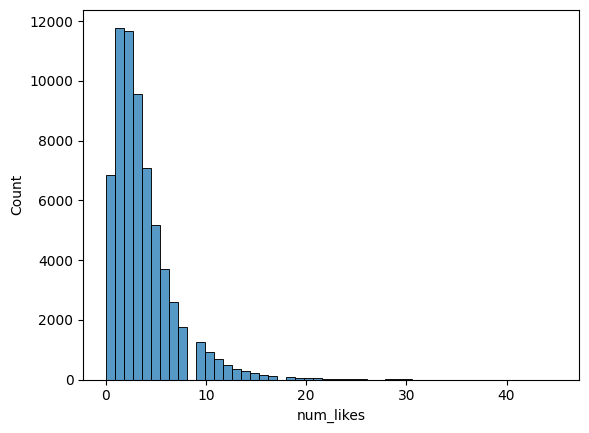

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(final_df['num_likes'], bins=50)
plt.show()

## U-критерий *Манна-Уитни* (англ. Mann–Whitney U test) — непараметрический статистический критерий, используемый для оценки различий между двумя независимыми выборками по уровню какого-либо признака, измеренного количественно. 

* Суть метода: критерий не сравнивает средние значения напрямую, а ранжирует все наблюдения и анализирует распределение рангов между группами. Если распределение рангов в группах сильно отличается, можно сделать вывод, что различия между группами статистически значимы. 

* Методика расчета
1. Формулировка гипотез:
Нулевая гипотеза (H₀) — нет статистически значимых различий между распределениями двух выборок.
Альтернативная гипотеза (H₁) — распределения двух выборок различаются, значения из одной выборки систематически выше (или ниже) значений из другой.
Объединение и ранжирование:
2. Все значения из обеих групп объединяются в один общий ряд и упорядочиваются от меньшего к большему. Каждому значению присваивается ранг — его порядковый номер. Если в ряду есть одинаковые значения, им присваивается средний ранг.
3. Расчёт сумм рангов:
После ранжирования данные снова разделяют на исходные группы, для каждой группы считают сумму рангов.
4. Расчёт U-статистик:
Вычисляют две эмпирические статистики — U₁ и U₂ — по формулам.
В качестве итоговой статистики U-критерия берётся минимальное из двух полученных значений.
 
* Ограничения
Некоторые ограничения применимости критерия:
- В каждой из выборок должно быть не менее 3 значений признака. Допускается, чтобы в одной выборке было два значения, но во второй тогда — не менее пяти. 
- В выборочных данных не должно быть совпадающих значений (все числа — разные) или таких совпадений должно быть очень мало (до 10). 
- Нельзя использовать для связанных выборок — в этом случае применяют критерий Уилкоксона. 

- Менее мощный, чем параметрический t-тест, если данные всё же нормальны. 
- Не определяет, насколько отличаются группы — только факт различий.
* Интерпретация результатов

- Если p < 0,05 (или выбранного уровня α) — существуют статистически значимые различия в распределениях двух групп.
- Если p ≥ 0,05 — нет достаточных оснований утверждать, что между группами есть разница. Это не доказывает, что разницы нет, а означает, что на имеющихся данных они не обнаружены.
 
Важно: критерий Манна-Уитни не говорит, какая группа «лучше» — он лишь показывает, что распределения различаются. 


In [15]:
from scipy.stats import mannwhitneyu
from scipy import stats

mannwhitneyu(
    final_df[final_df.exp_group == 'control'].num_likes,
    final_df[final_df.exp_group == 'test'].num_likes,
)

MannwhitneyuResult(statistic=np.float64(518358073.0), pvalue=np.float64(2.9585062792441964e-05))

#### p_value очень маленький --> можно сделать вывод что существуют статистически различия в распределениях двух групп

# Формула для z-статистики:

$$z = \frac{p_1 - p_2}{\sqrt{p_{\text{pooled}}(1 - p_{\text{pooled}})\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}$$

где:

- $p_1$ и $p_2$ — доли пользователей с хотя бы одним лайком в тестовой и контрольной группах.
- $n_1$ и $n_2$ — размеры выборок (количество пользователей в каждой группе).
- $p_{\text{pooled}}$ — пулевая пропорция, которая рассчитывается как:

$$p_{\text{pooled}} = \frac{X_1 + X_2}{n_1 + n_2}$$

где:

- $X_1$ — количество пользователей с хотя бы одним лайком в тестовой группе.
- $X_2$ — количество пользователей с хотя бы одним лайком в контрольной группе.
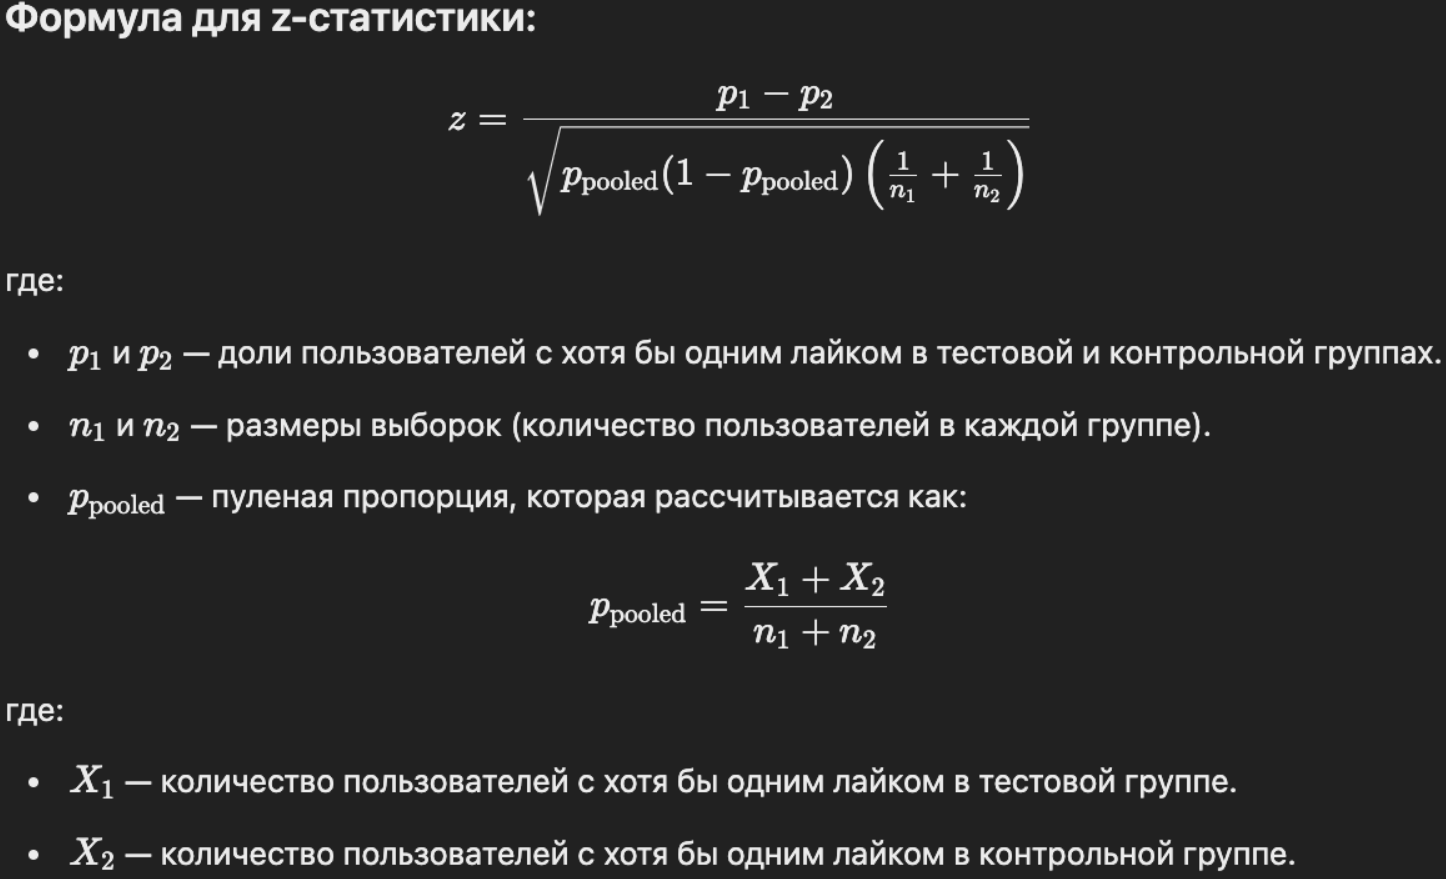

In [16]:
test_group = final_df[final_df['exp_group'] == 'test']
control_group = final_df[final_df['exp_group'] == 'control']

n1 = test_group.shape[0]
n2 = control_group.shape[0]

p1 = test_group[test_group['num_likes'] > 0].shape[0] / test_group.shape[0]
p2 = control_group[control_group['num_likes'] > 0].shape[0] / control_group.shape[0]

x1 = test_group[test_group['num_likes'] > 0].shape[0]
x2 = control_group[control_group['num_likes'] > 0].shape[0]

p_pooled = (x1 + x2) / (n1 + n2)

z_test = (p1 - p2) / np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))
print(z_test)

2.8440248969682322


In [17]:
p_value = 2 * (1 - stats.norm.cdf(abs(z_test)))
print(f'p value = {p_value}')

alpha = 0.05
if p_value < alpha:
    print('есть различия')
else:
    print('нет различий')

p value = 0.0044547566854864495
есть различия


посчитаем hitrate (или долю рекомендаций, в которые пользователи кликнули). Для этого мы хотим собрать в одной табличке информацию о показанных постах и соответствующих кликах.

У нас нет айдишника, по которому мы можем сджойнить, но есть два других способа сделать это:

* По каждому пользователю отсортировать в обратном по времени порядке все лайки и показы рекомендаций (удобнее прямо в одном списке). Далее в цикле пробежаться по этому списку. Если мы встречаем лайк, то запоминаем его (лайков может быть несколько подряд, надо сохранить все). Если мы встречаем показ рекомендаций, то сохраняем его вместе с уже сохранёнными лайками (так как эти лайки следуют за этим показом рекомендаций в "обычном направлении времени"), при этом список сохранёных лайков очищаем (мы уже приписали эти лайки другим показам). Тем самым мы соединим все показы рекомендаций со всеми лайками после них. Нужно только ещё следить за тем, что может быть лайк, который случился через большое время после показа рекомендаций — скорее всего, мы потеряли другой показ рекомендаций, поэтому такой лайк не надо учитывать.
* Сделать join по пользователям всех лайков и всех показов рекомендаций (то есть у нас появятся пары всех показов и всех лайков одного и того же пользователя, но не все эти пары реальны). Далее отфильтровать те ситуации, где лайк предшествовал показу рекомендаций (то есть относился на самом деле к другому показу) или был слишком поздно (тоже относится к другому показу).
Оба эти способа не идеальные и довольно муторные. В pandas проще сделать второй из них. Попробуйте сделать его. В качестве проверки "лайк произошёл слишком поздно после рекомендации" возьмите отсечку 1 час (только лучше сначала просто помечать такие показы, как "отсутствие лайка", потому что если совсем удалять, то можно потерять показ). Добавьте также фильтрацию на то, что в рекомендациях был пост, на который пользователь лайкнул (иначе это точно был другой показ). В самом конце проведите уникализацию всех этих пар в строки показ-лайки (количество лайков может быть нулевым).

На каждом этапе фильтрации следите за размерами таблиц, это поможет вам убедиться, что происходит что-то корректное. Не забудьте учесть тот факт, что могут быть показы рекомендаций без лайков (либо через тип join, либо добавить эти строки в конце). В итоге число строк должно быть похожим на то, которые было сначала в табличке с показами.


  Делаем так:

  1. Объединяем два датафрейма - с показами и кликами. Нужно подобрать такой джойн, чтобы остались и показы без кликов.

  2. Разбиваем значения в списке рекомендаций на отдельные - могут помочь [.str.split()](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html), [str.replace()](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html)

  3. Помечаем все **ненужные** нам посты. Это те, у которых **нет id** (стоит пропуск в `post_id`), которые **лайкнули позже, чем через час**, в которых **просмотр оказался позже лайка**, а также те, которые **не рекомендовали**

  4. Самое сложное: для каждого юзера/поста/просмотра подбираем количество лайков, связанное именно с этой комбинацией. То есть лайкнул человек этот пост после показа или нет, 1 или 0, True или False. При этом учитывайте условия из прошлого шага - все эти варианты считаются за 0/False. Вот это и будет наш **hitrate**

  5. Остаётся лишь посчитать относительную частоту лайкания



In [18]:
df = pd.merge(df_views_clean, df_likes_clean, on='user_id', how='left',  indicator=True)
df

,user_id,exp_group,recommendations,timestamp_x,post_id,timestamp_y,_merge
0,128381,control,[3644 4529 4704 5294 4808],1654030803,4704.0,1.654031e+09,both
1,128381,control,[3644 4529 4704 5294 4808],1654030803,5294.0,1.654031e+09,both
2,128381,control,[3644 4529 4704 5294 4808],1654030803,3608.0,1.655049e+09,both
3,128381,control,[3644 4529 4704 5294 4808],1654030803,2542.0,1.655049e+09,both
4,128381,control,[3644 4529 4704 5294 4808],1654030803,4165.0,1.655053e+09,both
...,...,...,...,...,...,...,...
1016884,52169,test,[1368 1709 1616 798 5305],1655240354,1709.0,1.655240e+09,both
1016885,142402,test,[5895 6984 1978 6548 6106],1655240373,6548.0,1.655240e+09,both
1016886,72259,control,[6117 1255 6567 3587 3811],1655240388,1712.0,1.654305e+09,both
1016887,72259,control,[6117 1255 6567 3587 3811],1655240388,5070.0,1.654309e+09,both


In [19]:
df['recommendations'] = df['recommendations'].astype(str)
df['recommendations'] = df['recommendations'].str.replace(r'[\[\]]', '', regex=True)
df['recommendations'] = df['recommendations'].str.split()
df['recommendations'] = df['recommendations'].apply(lambda x: list(map(int, x)))

In [20]:
df['timestamp_x'] = pd.to_datetime(df['timestamp_x'])
df['timestamp_y'] = pd.to_datetime(df['timestamp_y'])

In [21]:
df

,user_id,exp_group,recommendations,timestamp_x,post_id,timestamp_y,_merge
0,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,4704.0,1970-01-01 00:00:01.654030804,both
1,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,5294.0,1970-01-01 00:00:01.654030838,both
2,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,3608.0,1970-01-01 00:00:01.655049327,both
3,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,2542.0,1970-01-01 00:00:01.655049342,both
4,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,4165.0,1970-01-01 00:00:01.655052806,both
...,...,...,...,...,...,...,...
1016884,52169,test,"[1368, 1709, 1616, 798, 5305]",1970-01-01 00:00:01.655240354,1709.0,1970-01-01 00:00:01.655240369,both
1016885,142402,test,"[5895, 6984, 1978, 6548, 6106]",1970-01-01 00:00:01.655240373,6548.0,1970-01-01 00:00:01.655240374,both
1016886,72259,control,"[6117, 1255, 6567, 3587, 3811]",1970-01-01 00:00:01.655240388,1712.0,1970-01-01 00:00:01.654305111,both
1016887,72259,control,"[6117, 1255, 6567, 3587, 3811]",1970-01-01 00:00:01.655240388,5070.0,1970-01-01 00:00:01.654308590,both


In [22]:
df['hit'] = True  # Изначально все записи считаем валидными

df.loc[df['post_id'].isna(), 'hit'] = False
df.loc[(df['timestamp_y'] - df['timestamp_x']) > pd.Timedelta(hours=1), 'hit'] = False
df.loc[df['timestamp_x'] > df['timestamp_y'], 'hit'] = False


def post_in_recommendations(row):
    """
    Проверяет, находится ли post_id в списке recommendations для данной строки
    """
    try:
        return row['post_id'] in row['recommendations']
    except:
        return False

df['is_recommended'] = df.apply(post_in_recommendations, axis=1)
df['hit'] = df['hit'] & df['is_recommended']
df['liked'] = df['hit'].astype(int)
df_grouped = df.groupby(['user_id', 'exp_group', 'timestamp_x'])['liked'].max().reset_index()

total_shows = len(df_grouped)
total_likes = df_grouped['liked'].sum()
hitrate_overall = total_likes / total_shows

print(f"hitrate: {hitrate_overall:.2%}")

Общий hitrate: 71.38%


In [23]:
df

,user_id,exp_group,recommendations,timestamp_x,post_id,timestamp_y,_merge,hit,is_recommended,liked
0,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,4704.0,1970-01-01 00:00:01.654030804,both,True,True,1
1,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,5294.0,1970-01-01 00:00:01.654030838,both,True,True,1
2,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,3608.0,1970-01-01 00:00:01.655049327,both,False,False,0
3,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,2542.0,1970-01-01 00:00:01.655049342,both,False,False,0
4,128381,control,"[3644, 4529, 4704, 5294, 4808]",1970-01-01 00:00:01.654030803,4165.0,1970-01-01 00:00:01.655052806,both,False,False,0
...,...,...,...,...,...,...,...,...,...,...
1016884,52169,test,"[1368, 1709, 1616, 798, 5305]",1970-01-01 00:00:01.655240354,1709.0,1970-01-01 00:00:01.655240369,both,True,True,1
1016885,142402,test,"[5895, 6984, 1978, 6548, 6106]",1970-01-01 00:00:01.655240373,6548.0,1970-01-01 00:00:01.655240374,both,True,True,1
1016886,72259,control,"[6117, 1255, 6567, 3587, 3811]",1970-01-01 00:00:01.655240388,1712.0,1970-01-01 00:00:01.654305111,both,False,False,0
1016887,72259,control,"[6117, 1255, 6567, 3587, 3811]",1970-01-01 00:00:01.655240388,5070.0,1970-01-01 00:00:01.654308590,both,False,False,0


А теперь давайте оценим различие между группами и значимость. z-критерий для долей мы здесь не можем применять, так как у нас в каждой выборке один и тот же пользователь может встречаться несколько раз. Давайте применим бакетный подход (то есть перейдём к бакетам и по ним оценим значимость), чтобы посчитать групповой hitrate (или CTR) — доля hitrate по группе/бакету. Используйте 100 бакетов. Уровень значимости останется тем же на уровне 0.05.

In [34]:
import hashlib

df_grouped['bucket'] = df_grouped['user_id'].apply(
    lambda x: int(hashlib.md5((str(x) + 'my_salt').encode()).hexdigest(), 16) % 100
)

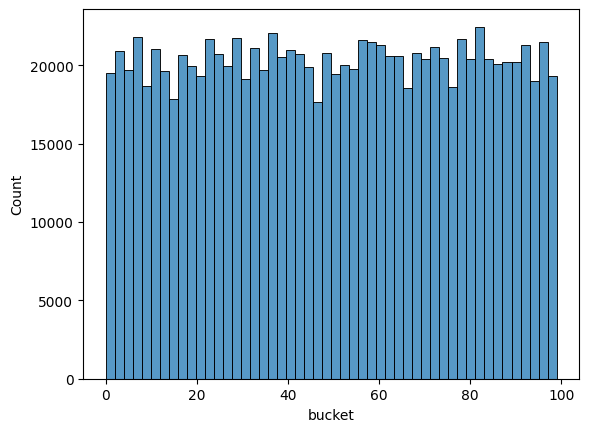

In [35]:
sns.histplot(df.bucket, bins=50)
plt.show()

In [36]:
bucket_stats = df_grouped.groupby(['exp_group', 'bucket']).agg(
    hitrate=('liked', 'mean')
).reset_index()

In [37]:
control = bucket_stats[bucket_stats['exp_group'] == 'control']['hitrate']
test = bucket_stats[bucket_stats['exp_group'] == 'test']['hitrate']

In [38]:
t_stat, p_value = stats.ttest_ind(control, test)

print(f"p-value = {p_value:.4f}")
print("Статистически значимо" if p_value < 0.05 else "Не значимо")
print(f"Control hitrate: {control.mean():.4f} ± {control.std():.4f}")
print(f"Test hitrate:    {test.mean():.4f} ± {test.std():.4f}")

p-value = 0.0000
Статистически значимо
Control hitrate: 0.7070 ± 0.0160
Test hitrate:    0.7206 ± 0.0170
